## 📦 Cell 1: Install Required Libraries

In [1]:
# Install Gradio for deployment
!pip install gradio scikit-learn pandas numpy matplotlib seaborn tensorflow -q
print('✅ All libraries installed successfully!')

✅ All libraries installed successfully!


## 📂 Cell 2: Upload Dataset

In [2]:
from google.colab import files
print('Please upload your COVID-19 CSV file (e.g., 01-01-2021.csv)')
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f'✅ Uploaded: {CSV_PATH}')

Please upload your COVID-19 CSV file (e.g., 01-01-2021.csv)


Saving 01-01-2021.csv to 01-01-2021.csv
✅ Uploaded: 01-01-2021.csv


## 📊 Cell 3: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'✅ TensorFlow version: {tf.__version__}')
print(f'✅ Libraries loaded successfully!')

✅ TensorFlow version: 2.19.0
✅ Libraries loaded successfully!


## 🔍 Cell 4: Load and Explore the Dataset

In [4]:
# Load the dataset
df = pd.read_csv(CSV_PATH)

print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
Rows: 4011, Columns: 14

=== Column Names ===
['FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Last_Update', 'Lat', 'Long_', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'Combined_Key', 'Incident_Rate', 'Case_Fatality_Ratio']

=== First 5 Rows ===


,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-01-02 05:22:33,33.93911,67.709953,52513,2201,41727,8585,Afghanistan,134.896578,4.191343
1,NaN,NaN,NaN,Albania,2021-01-02 05:22:33,41.15330,20.168300,58316,1181,33634,23501,Albania,2026.409062,2.025173
2,NaN,NaN,NaN,Algeria,2021-01-02 05:22:33,28.03390,1.659600,99897,2762,67395,29740,Algeria,227.809861,2.764848
3,NaN,NaN,NaN,Andorra,2021-01-02 05:22:33,42.50630,1.521800,8117,84,7463,570,Andorra,10505.403482,1.034865
4,NaN,NaN,NaN,Angola,2021-01-02 05:22:33,-11.20270,17.873900,17568,405,11146,6017,Angola,53.452981,2.305328


In [5]:
# Basic statistics
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4011 entries, 0 to 4010
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FIPS                 3265 non-null   float64
 1   Admin2               3270 non-null   object 
 2   Province_State       3833 non-null   object 
 3   Country_Region       4011 non-null   object 
 4   Last_Update          4011 non-null   object 
 5   Lat                  3922 non-null   float64
 6   Long_                3922 non-null   float64
 7   Confirmed            4011 non-null   int64  
 8   Deaths               4011 non-null   int64  
 9   Recovered            4011 non-null   int64  
 10  Active               4011 non-null   int64  
 11  Combined_Key         4011 non-null   object 
 12  Incident_Rate        3922 non-null   float64
 13  Case_Fatality_Ratio  3963 non-null   float64
dtypes: float64(5), int64(4), object(5)
memory usage: 438.8+ KB

=== Sta

,FIPS,Lat,Long_,Confirmed,Deaths,Recovered,Active,Incident_Rate,Case_Fatality_Ratio
count,3265.000000,3922.000000,3922.000000,4.011000e+03,4011.000000,4.011000e+03,4.011000e+03,3922.000000,3963.000000
mean,32386.688208,35.768908,-71.113714,2.102613e+04,476.518823,1.180731e+04,9.259591e+03,5738.940929,2.228699
std,18017.294540,13.391261,55.220345,1.055172e+05,2833.090464,8.193885e+04,5.719777e+04,3227.374130,17.174874
min,66.000000,-71.949900,-175.198200,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,19049.000000,33.202974,-96.580090,7.010000e+02,9.000000,0.000000e+00,5.780000e+02,3536.967442,0.969239
50%,30067.000000,37.910342,-86.708116,1.968000e+03,31.000000,0.000000e+00,1.657000e+03,5840.344304,1.551567
75%,47039.000000,42.181730,-77.358102,7.693500e+03,112.000000,0.000000e+00,4.915500e+03,7752.568815,2.341350
max,99999.000000,71.706900,178.065000,2.636045e+06,81593.000000,2.114760e+06,2.400750e+06,27388.219766,1026.206897


In [6]:
# Check missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
                     Missing Count  Missing %
FIPS                           746  18.598853
Admin2                         741  18.474196
Province_State                 178   4.437796
Lat                             89   2.218898
Long_                           89   2.218898
Incident_Rate                   89   2.218898
Case_Fatality_Ratio             48   1.196709


## 🧹 Cell 5: Data Preprocessing

In [7]:
# ─── Feature Selection ───
# Select numeric features relevant for predicting Case_Fatality_Ratio
FEATURES = ['Confirmed', 'Deaths', 'Recovered', 'Active', 'Incident_Rate']
TARGET   = 'Case_Fatality_Ratio'

# Drop rows where target or features are missing
df_clean = df[FEATURES + [TARGET]].dropna()

# Remove rows with negative or zero Confirmed cases (data quality)
df_clean = df_clean[df_clean['Confirmed'] > 0]

# Remove outliers in target (CFR > 100 is impossible)
df_clean = df_clean[(df_clean[TARGET] >= 0) & (df_clean[TARGET] <= 100)]

print(f'✅ Clean dataset size: {df_clean.shape[0]} rows')
print(f'\nFeatures used: {FEATURES}')
print(f'Target: {TARGET}')
df_clean.describe()

✅ Clean dataset size: 3906 rows

Features used: ['Confirmed', 'Deaths', 'Recovered', 'Active', 'Incident_Rate']
Target: Case_Fatality_Ratio


,Confirmed,Deaths,Recovered,Active,Incident_Rate,Case_Fatality_Ratio
count,3.906000e+03,3906.000000,3.906000e+03,3.906000e+03,3906.000000,3906.000000
mean,2.154107e+04,483.101126,1.159061e+04,9.464148e+03,5761.989805,1.851970
std,1.068754e+05,2853.521225,7.981379e+04,5.794112e+04,3213.657133,1.575149
min,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,7.535000e+02,10.000000,0.000000e+00,6.275000e+02,3588.862461,0.984892
50%,2.029000e+03,33.000000,0.000000e+00,1.716000e+03,5859.653512,1.562500
75%,7.977000e+03,117.750000,0.000000e+00,5.065000e+03,7760.520948,2.349809
max,2.636045e+06,81593.000000,2.114760e+06,2.400750e+06,27388.219766,29.033793


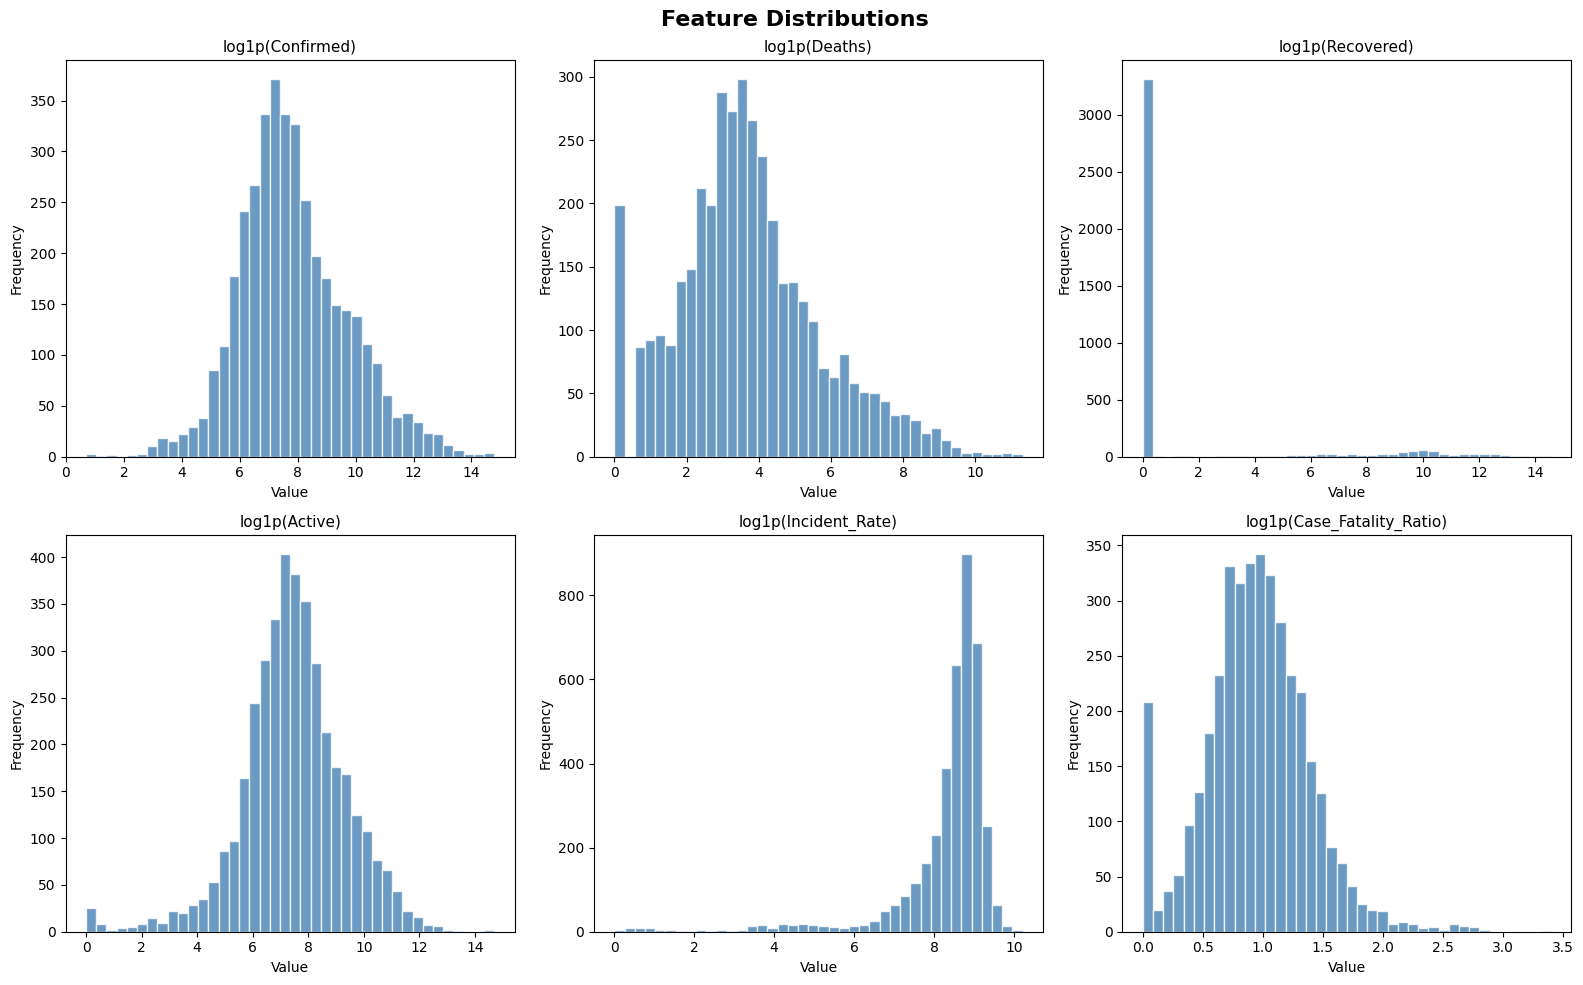

✅ Distribution plot saved!


In [8]:
# ─── Exploratory Visualizations ───
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

all_cols = FEATURES + [TARGET]
for i, col in enumerate(all_cols):
    ax = axes[i // 3][i % 3]
    ax.hist(np.log1p(df_clean[col]), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'log1p({col})', fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Distribution plot saved!')

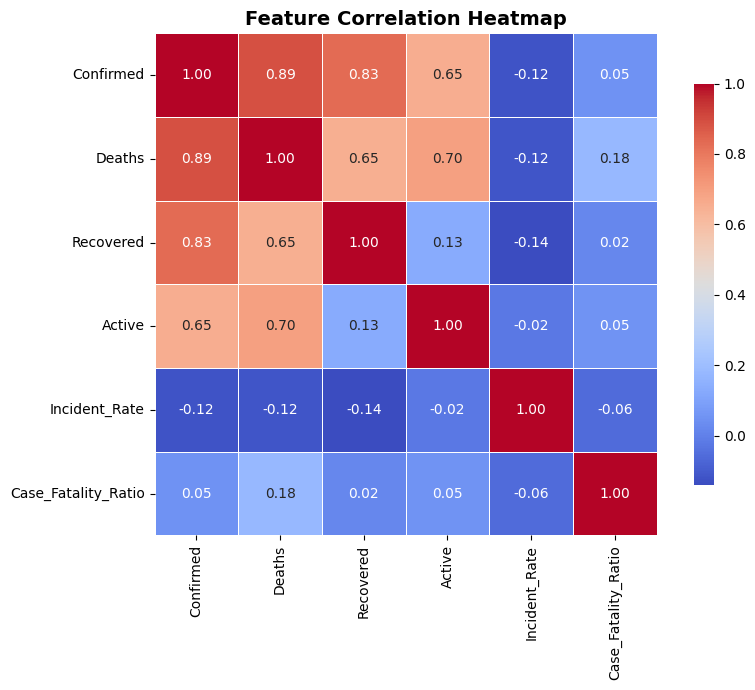

✅ Correlation heatmap saved!


In [9]:
# ─── Correlation Heatmap ───
plt.figure(figsize=(9, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap saved!')

In [10]:
# ─── Train / Validation / Test Split ───
X = df_clean[FEATURES].values
y = df_clean[TARGET].values

# Apply log1p transform to reduce skewness in features
X = np.log1p(X)

# 70% train | 15% validation | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# ─── Feature Scaling ───
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'Train size:      {X_train_sc.shape[0]}')
print(f'Validation size: {X_val_sc.shape[0]}')
print(f'Test size:       {X_test_sc.shape[0]}')

Train size:      2734
Validation size: 586
Test size:       586


## 🏗️ Cell 6: Build ANN Model

In [11]:
def build_ann(input_dim):
    """
    Standard Artificial Neural Network (Deep path only).
    Architecture:
        Input → Dense(128) → BN → Dropout(0.3)
              → Dense(64)  → BN → Dropout(0.2)
              → Dense(32)  → BN
              → Dense(1)  (linear output for regression)
    """
    model = keras.Sequential([
        # Hidden Layer 1
        layers.Dense(128, activation='relu', input_shape=(input_dim,),
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden Layer 2
        layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Hidden Layer 3
        layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),

        # Output Layer (regression → linear activation)
        layers.Dense(1, activation='linear')
    ], name='ANN_Model')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

ann_model = build_ann(X_train_sc.shape[1])
ann_model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 11,585 (45.25 KB)

 Non-trainable params: 448 (1.75 KB)

## 🏗️ Cell 7: Build Wide & Deep Model

In [12]:
def build_wide_and_deep(input_dim):
    """
    Wide & Deep Neural Network.

    WIDE path  → Direct linear connection (memorization)
    DEEP path  → Stacked dense layers     (generalization)

    Both paths are CONCATENATED before the final output layer.
    This allows the model to memorize feature interactions (wide)
    while also learning complex non-linear patterns (deep).
    """
    inputs = Input(shape=(input_dim,), name='Input')

    # ── WIDE path (linear) ──────────────────────────────
    wide = layers.Dense(input_dim, activation='linear', name='Wide_Linear')(inputs)

    # ── DEEP path (non-linear) ──────────────────────────
    deep = layers.Dense(128, activation='relu',
                        kernel_initializer='he_normal', name='Deep_1')(inputs)
    deep = layers.BatchNormalization(name='BN_1')(deep)
    deep = layers.Dropout(0.3, name='Drop_1')(deep)

    deep = layers.Dense(64, activation='relu',
                        kernel_initializer='he_normal', name='Deep_2')(deep)
    deep = layers.BatchNormalization(name='BN_2')(deep)
    deep = layers.Dropout(0.2, name='Drop_2')(deep)

    deep = layers.Dense(32, activation='relu',
                        kernel_initializer='he_normal', name='Deep_3')(deep)
    deep = layers.BatchNormalization(name='BN_3')(deep)

    # ── Concatenate Wide + Deep ──────────────────────────
    combined = layers.Concatenate(name='Wide_Deep_Concat')([wide, deep])

    # ── Output Layer ────────────────────────────────────
    output = layers.Dense(1, activation='linear', name='Output')(combined)

    model = Model(inputs=inputs, outputs=output, name='Wide_and_Deep_Model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

wd_model = build_wide_and_deep(X_train_sc.shape[1])
wd_model.summary()

Model: "Wide_and_Deep_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_1 (Dense)      │ (None, 128)       │        768 │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_1                │ (None, 128)       │        512 │ Deep_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Drop_1 (Dropout)    │ (None, 128)       │          0 │ BN_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_2 (Dense)      │ (None, 64)        │      8,256 │ Drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_2                │ (None, 64)        │        256 │ Deep_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Drop_2 (Dropout)    │ (None, 64)        │          0 │ BN_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Deep_3 (Dense)      │ (None, 32)        │      2,080 │ Drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wide_Linear (Dense) │ (None, 5)         │         30 │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_3                │ (None, 32)        │        128 │ Deep_3[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wide_Deep_Concat    │ (None, 37)        │          0 │ Wide_Linear[0][0… │
│ (Concatenate)       │                   │            │ BN_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 1)         │         38 │ Wide_Deep_Concat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,068 (47.14 KB)

 Trainable params: 11,620 (45.39 KB)

 Non-trainable params: 448 (1.75 KB)

## 🚀 Cell 8: Train ANN Model

In [13]:
# ─── Callbacks ───
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

print('🏋️ Training ANN Model...')
ann_history = ann_model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=15,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print('✅ ANN training complete!')

🏋️ Training ANN Model...
Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 4.8270 - mae: 1.6945 - val_loss: 3.1953 - val_mae: 1.5991 - learning_rate: 0.0010
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.6198 - mae: 1.1611 - val_loss: 1.7140 - val_mae: 1.1221 - learning_rate: 0.0010
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.4708 - mae: 0.7849 - val_loss: 0.6657 - val_mae: 0.6414 - learning_rate: 0.0010
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1708 - mae: 0.6444 - val_loss: 0.4565 - val_mae: 0.5075 - learning_rate: 0.0010
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0644 - mae: 0.6015 - val_loss: 0.3589 - val_mae: 0.4174 - learning_rate: 0.0010
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9970 - mae: 0.5703 - val_loss: 0.3241 - val_mae: 0.4139 - learning_rate: 0.0010
Epoch 7/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9740 - mae: 0.5705 - val_loss: 0.2726 - val_mae: 0.3449 - learning_rate:

## 🚀 Cell 9: Train Wide & Deep Model

In [15]:
print('🏋️ Training Wide & Deep Model...')
wd_history = wd_model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=15,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print('✅ Wide & Deep training complete!')

🏋️ Training Wide & Deep Model...
Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4692 - mae: 0.3775 - val_loss: 0.0930 - val_mae: 0.1626 - learning_rate: 1.5625e-05
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4194 - mae: 0.3683 - val_loss: 0.0947 - val_mae: 0.1649 - learning_rate: 1.5625e-05
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4084 - mae: 0.3782 - val_loss: 0.0965 - val_mae: 0.1670 - learning_rate: 1.5625e-05
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.4466 - mae: 0.3783 - val_loss: 0.0965 - val_mae: 0.1679 - learning_rate: 1.5625e-05
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4164 - mae: 0.3753 - val_loss: 0.0960 - val_mae: 0.1666 - learning_rate: 1.5625e-05
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4588 - mae: 0.3762 - val_loss: 0.0960 - val_mae: 0.1654 - learning_rate: 1.5625e-05
Epoch 7/15
84/86 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3644 - mae: 0.3733
Epoch 7: ReduceLRO

## 📈 Cell 10: Training History Plots

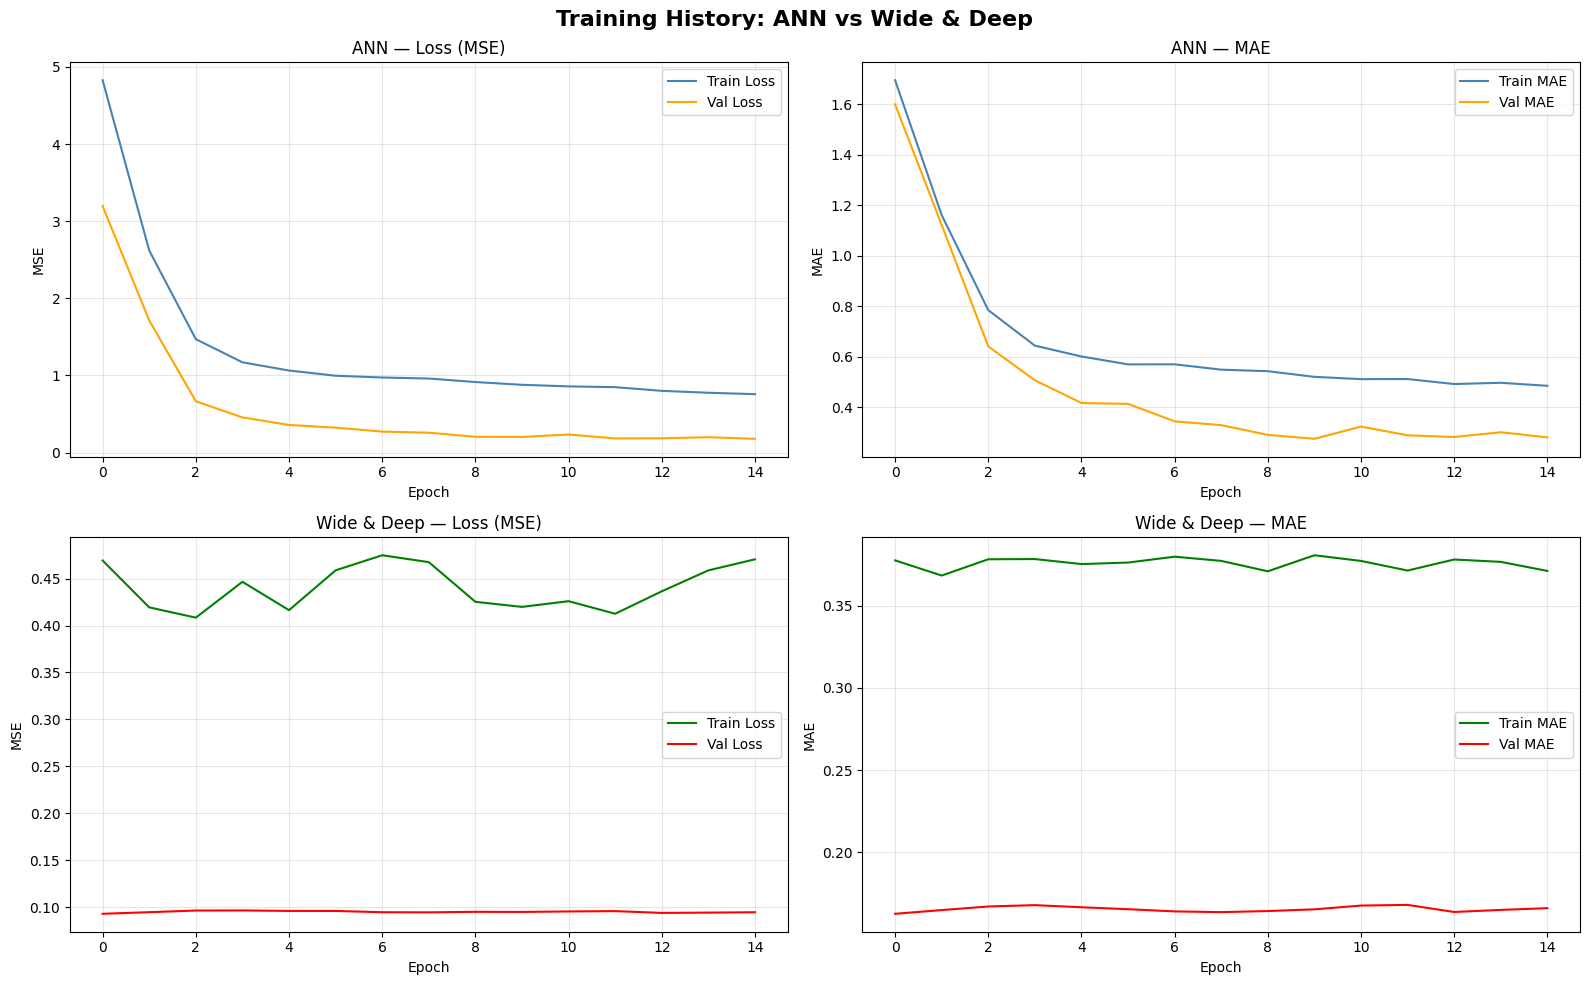

✅ Training history plot saved!


In [16]:
def plot_training_history(ann_hist, wd_hist):
    """Plot loss and MAE curves for both models side by side."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Training History: ANN vs Wide & Deep', fontsize=16, fontweight='bold')

    # ANN Loss
    axes[0][0].plot(ann_hist.history['loss'], label='Train Loss', color='steelblue')
    axes[0][0].plot(ann_hist.history['val_loss'], label='Val Loss', color='orange')
    axes[0][0].set_title('ANN — Loss (MSE)')
    axes[0][0].set_xlabel('Epoch'); axes[0][0].set_ylabel('MSE')
    axes[0][0].legend(); axes[0][0].grid(True, alpha=0.3)

    # ANN MAE
    axes[0][1].plot(ann_hist.history['mae'], label='Train MAE', color='steelblue')
    axes[0][1].plot(ann_hist.history['val_mae'], label='Val MAE', color='orange')
    axes[0][1].set_title('ANN — MAE')
    axes[0][1].set_xlabel('Epoch'); axes[0][1].set_ylabel('MAE')
    axes[0][1].legend(); axes[0][1].grid(True, alpha=0.3)

    # W&D Loss
    axes[1][0].plot(wd_hist.history['loss'], label='Train Loss', color='green')
    axes[1][0].plot(wd_hist.history['val_loss'], label='Val Loss', color='red')
    axes[1][0].set_title('Wide & Deep — Loss (MSE)')
    axes[1][0].set_xlabel('Epoch'); axes[1][0].set_ylabel('MSE')
    axes[1][0].legend(); axes[1][0].grid(True, alpha=0.3)

    # W&D MAE
    axes[1][1].plot(wd_hist.history['mae'], label='Train MAE', color='green')
    axes[1][1].plot(wd_hist.history['val_mae'], label='Val MAE', color='red')
    axes[1][1].set_title('Wide & Deep — MAE')
    axes[1][1].set_xlabel('Epoch'); axes[1][1].set_ylabel('MAE')
    axes[1][1].legend(); axes[1][1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Training history plot saved!')

plot_training_history(ann_history, wd_history)

## 📊 Cell 11: Evaluate Both Models on Test Set

In [17]:
def evaluate_model(model, X_test, y_test, model_name):
    """Compute and print regression metrics for a given model."""
    y_pred = model.predict(X_test).flatten()

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f'\n{'='*45}')
    print(f'  📋 {model_name} — Test Set Metrics')
    print(f'{'='*45}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'{'='*45}')

    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

ann_results = evaluate_model(ann_model, X_test_sc, y_test, 'ANN')
wd_results  = evaluate_model(wd_model,  X_test_sc, y_test, 'Wide & Deep')

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

  📋 ANN — Test Set Metrics
  MSE  : 0.3622
  RMSE : 0.6019
  MAE  : 0.3286
  R²   : 0.8190
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

  📋 Wide & Deep — Test Set Metrics
  MSE  : 0.1780
  RMSE : 0.4219
  MAE  : 0.1881
  R²   : 0.9111


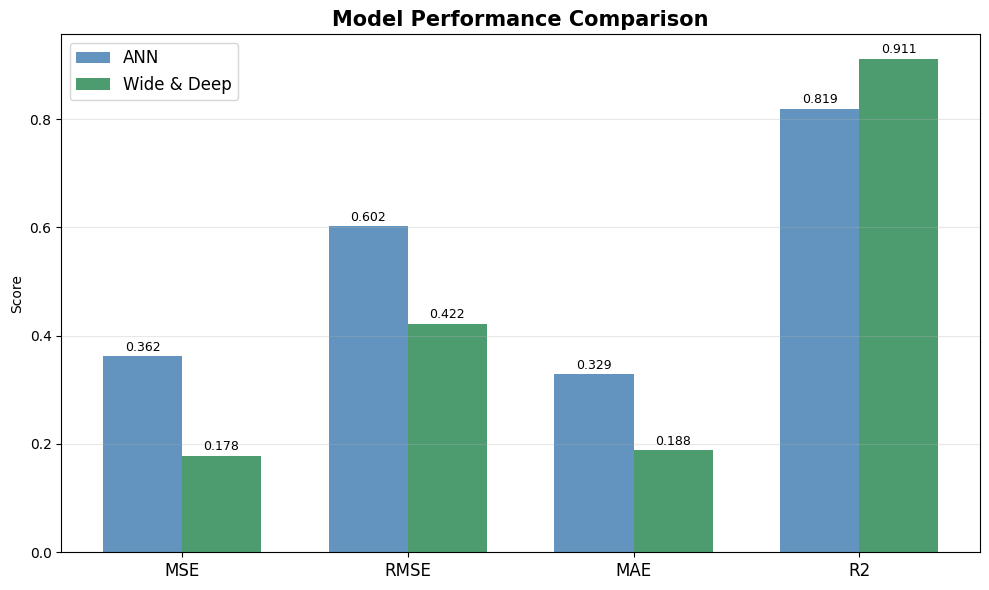

✅ Metrics comparison chart saved!


In [18]:
# ─── Metrics Comparison Bar Chart ───
metrics = ['MSE', 'RMSE', 'MAE', 'R2']
ann_vals = [ann_results[m] for m in metrics]
wd_vals  = [wd_results[m]  for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, ann_vals, width, label='ANN',         color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, wd_vals,  width, label='Wide & Deep', color='seagreen',  alpha=0.85)

ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Metrics comparison chart saved!')

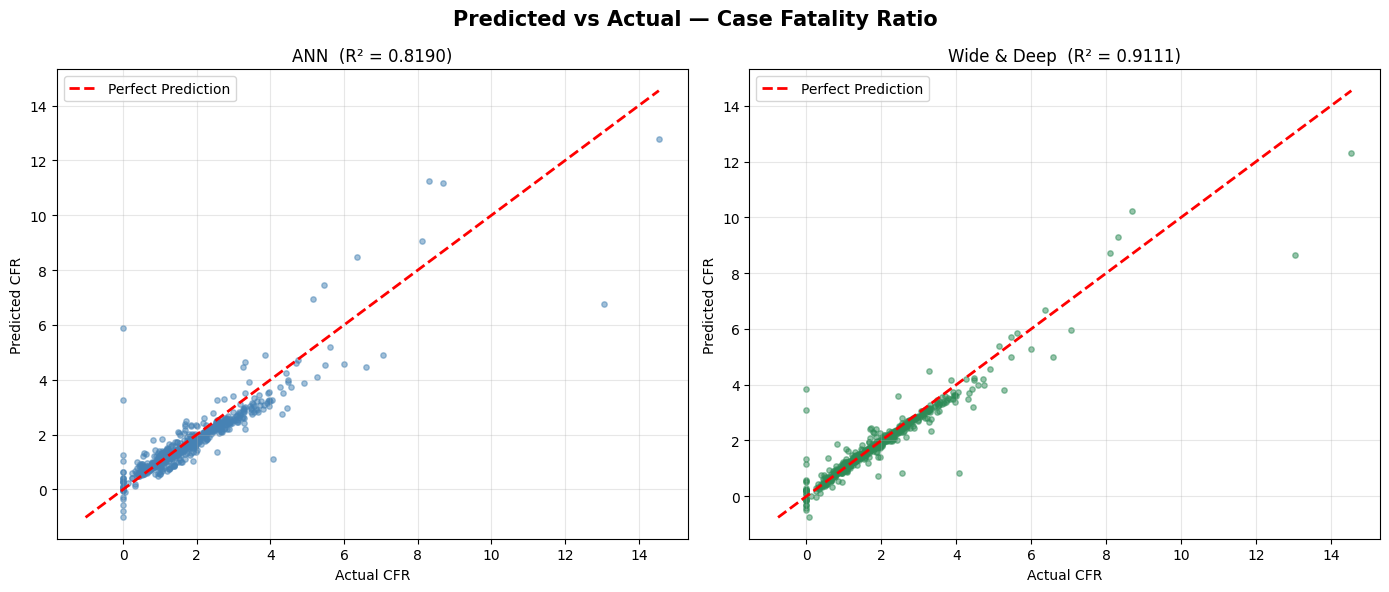

✅ Scatter plots saved!


In [19]:
# ─── Predicted vs Actual Scatter Plots ───
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicted vs Actual — Case Fatality Ratio', fontsize=15, fontweight='bold')

for ax, results, color, name in [
    (axes[0], ann_results, 'steelblue', 'ANN'),
    (axes[1], wd_results,  'seagreen',  'Wide & Deep')
]:
    y_p = results['y_pred']
    ax.scatter(y_test, y_p, alpha=0.5, color=color, s=15)
    lim = [min(y_test.min(), y_p.min()), max(y_test.max(), y_p.max())]
    ax.plot(lim, lim, 'r--', lw=2, label='Perfect Prediction')
    ax.set_title(f'{name}  (R² = {results["R2"]:.4f})')
    ax.set_xlabel('Actual CFR')
    ax.set_ylabel('Predicted CFR')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Scatter plots saved!')

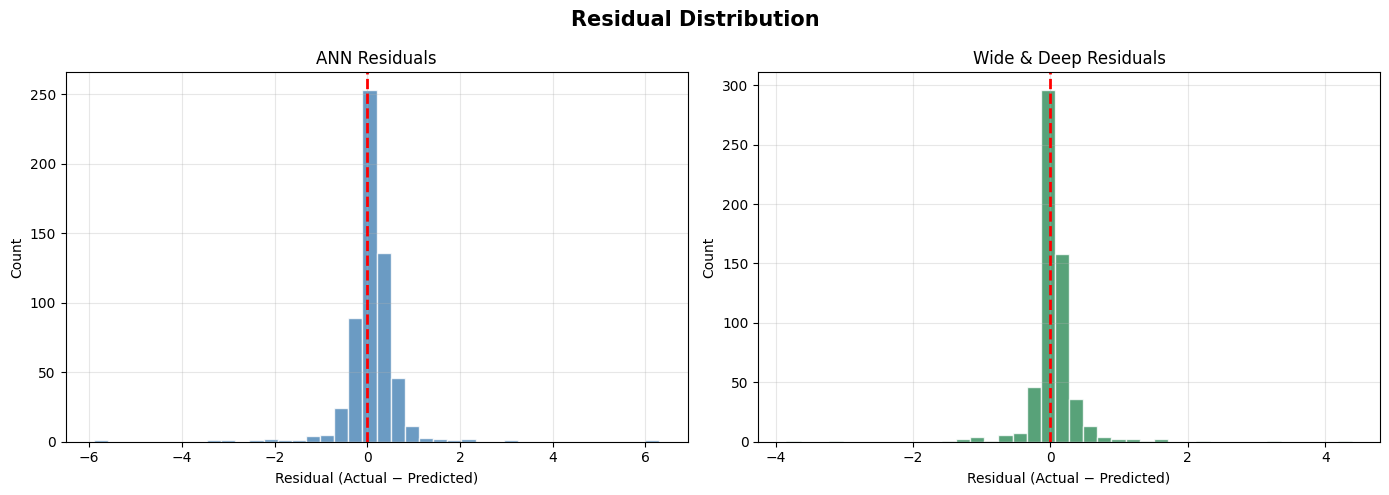

✅ Residual plots saved!


In [20]:
# ─── Residual Distribution Plot ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Distribution', fontsize=15, fontweight='bold')

for ax, results, color, name in [
    (axes[0], ann_results, 'steelblue', 'ANN'),
    (axes[1], wd_results,  'seagreen',  'Wide & Deep')
]:
    residuals = y_test - results['y_pred']
    ax.hist(residuals, bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'{name} Residuals')
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Residual plots saved!')

## 💾 Cell 12: Save Models

In [21]:
import pickle

# Save models in Keras format
ann_model.save('ann_model.keras')
wd_model.save('wide_deep_model.keras')

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print('✅ Models and scaler saved!')
print('   → ann_model.keras')
print('   → wide_deep_model.keras')
print('   → scaler.pkl')
print('   → features.pkl')

✅ Models and scaler saved!
   → ann_model.keras
   → wide_deep_model.keras
   → scaler.pkl
   → features.pkl


## 🌐 Cell 13: Deploy as a Website Using Gradio

In [ ]:
import gradio as gr
import pickle
import numpy as np

# ─── Load saved assets ───
ann_loaded = keras.models.load_model('ann_model.keras')
wd_loaded  = keras.models.load_model('wide_deep_model.keras')

with open('scaler.pkl', 'rb') as f:
    sc = pickle.load(f)

# ─── Prediction Function ───
def predict_cfr(confirmed, deaths, recovered, active, incident_rate, model_choice):
    """
    Takes COVID-19 statistics as input and returns
    the predicted Case Fatality Ratio (CFR).
    """
    try:
        # Build feature array and apply same transforms used during training
        features = np.array([[confirmed, deaths, recovered, active, incident_rate]], dtype=float)
        features = np.log1p(features)
        features = sc.transform(features)

        if model_choice == 'ANN':
            pred = ann_loaded.predict(features, verbose=0).flatten()[0]
        else:
            pred = wd_loaded.predict(features, verbose=0).flatten()[0]

        pred = max(0.0, round(float(pred), 4))  # CFR cannot be negative
        return f'✅ Predicted Case Fatality Ratio: {pred:.4f}%'

    except Exception as e:
        return f'❌ Error: {str(e)}'

# ─── Gradio Interface ───
demo = gr.Interface(
    fn=predict_cfr,
    inputs=[
        gr.Number(label='Confirmed Cases',  value=50000),
        gr.Number(label='Deaths',            value=1500),
        gr.Number(label='Recovered',         value=40000),
        gr.Number(label='Active Cases',      value=8500),
        gr.Number(label='Incident Rate',     value=300.0),
        gr.Radio(['ANN', 'Wide & Deep'], label='Select Model', value='Wide & Deep')
    ],
    outputs=gr.Textbox(label='Prediction Result'),
    title='🦠 COVID-19 Case Fatality Ratio Predictor',
    description=(
        'Enter COVID-19 statistics for a country/region to predict its '
        'Case Fatality Ratio (CFR) using ANN or Wide & Deep Neural Network.'
    ),
    examples=[
        [52513,  2201, 41727,  8585,  134.9, 'ANN'],
        [99897,  2762, 67395, 29740,  227.8, 'Wide & Deep'],
        [159738, 2828, 143355, 13555, 5390.6, 'Wide & Deep'],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True, debug=True)
print('✅ Gradio app launched! Use the public link above.')

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://fce2c236360f0d1a4f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 📋 Cell 14: Final Summary Table

In [ ]:
# ─── Final Performance Summary ───
summary = pd.DataFrame([
    {
        'Model':       'ANN',
        'MSE':         round(ann_results['MSE'],  4),
        'RMSE':        round(ann_results['RMSE'], 4),
        'MAE':         round(ann_results['MAE'],  4),
        'R² Score':    round(ann_results['R2'],   4),
        'Params':      ann_model.count_params()
    },
    {
        'Model':       'Wide & Deep',
        'MSE':         round(wd_results['MSE'],   4),
        'RMSE':        round(wd_results['RMSE'],  4),
        'MAE':         round(wd_results['MAE'],   4),
        'R² Score':    round(wd_results['R2'],    4),
        'Params':      wd_model.count_params()
    }
])

print('\n' + '='*60)
print('  🏆  FINAL MODEL PERFORMANCE COMPARISON')
print('='*60)
print(summary.to_string(index=False))
print('='*60)

# Determine best model
if ann_results['R2'] > wd_results['R2']:
    print('\n🥇 Best Model: ANN (higher R²)')
else:
    print('\n🥇 Best Model: Wide & Deep (higher R²)')

print('\n✅ All cells complete! Your assignment notebook is ready.')